In [15]:
# Import library here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import numpy as np

def apply_eda_driven_features(df):
    df = df.copy()
    
    # ---------------------------------------------------------
    # 1. Target Transformation (จัดการ Skewness ของเป้าหมาย)
    # ---------------------------------------------------------
    if 'Duration(min)' in df.columns:
        df['Log_Duration(min)'] = np.log1p(df['Duration(min)'])
    if 'Distance(mi)' in df.columns:
        df['Log_Distance(mi)'] = np.log1p(df['Distance(mi)'])

    # ---------------------------------------------------------
    # 2. Temporal Features (แกะข้อมูลเวลา)
    # ---------------------------------------------------------
    if 'Start_Time' in df.columns:
        df['Start_Time'] = pd.to_datetime(df['Start_Time'])
        df['Hour'] = df['Start_Time'].dt.hour
        df['DayOfWeek'] = df['Start_Time'].dt.dayofweek
        df['Month'] = df['Start_Time'].dt.month
        
        df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)
        df['Is_RushHour'] = df['Hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)
    
    if 'Sunrise_Sunset' in df.columns:
        df['Is_Daylight'] = (df['Sunrise_Sunset'] == 'Day').astype(int)

    # ---------------------------------------------------------
    # 3. Weather Conditions (จัดกลุ่มสภาพอากาศ)
    # ---------------------------------------------------------
    if 'Weather_Condition' in df.columns:
        weather = df['Weather_Condition'].str.lower().fillna('unknown')
        df['Weather_Group'] = 'clear' # ค่าเริ่มต้น
        
        df.loc[weather.str.contains('rain|drizzle|shower', na=False), 'Weather_Group'] = 'rain'
        df.loc[weather.str.contains('snow|sleet|ice|blizzard|wintry', na=False), 'Weather_Group'] = 'snow'
        df.loc[weather.str.contains('fog|mist|smoke|haze|dust', na=False), 'Weather_Group'] = 'low_visibility'
        df.loc[weather.str.contains('cloud|overcast', na=False), 'Weather_Group'] = 'cloudy'
        df.loc[weather.str.contains('thunder|t-storm|tornado', na=False), 'Weather_Group'] = 'storm'

    # ---------------------------------------------------------
    # 4. Road Complexity (ความซับซ้อนของพื้นที่เกิดเหตุ)
    # ---------------------------------------------------------
    poi_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 
                'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 
                'Traffic_Calming', 'Traffic_Signal']
    
    existing_poi = [col for col in poi_cols if col in df.columns]
    if existing_poi:
        for col in existing_poi:
            df[col] = df[col].astype(int)
        df['Road_Complexity_Score'] = df[existing_poi].sum(axis=1)

    # ---------------------------------------------------------
    # 5. Spatial Frequency Encoding (ข้อมูลเชิงพื้นที่)
    # ---------------------------------------------------------
    if 'City' in df.columns:
        city_freq = df['City'].value_counts() / len(df)
        df['City_Freq'] = df['City'].map(city_freq).fillna(0)
        
    if 'State' in df.columns:
        state_freq = df['State'].value_counts() / len(df)
        df['State_Freq'] = df['State'].map(state_freq).fillna(0)

    # ---------------------------------------------------------
    # 6. ลบคอลัมน์ที่ไม่พร้อมใช้งานเข้าโมเดล
    # ---------------------------------------------------------
    cols_to_drop = ['ID', 'Source', 'End_Time', 'Weather_Timestamp', 'Description', 
                    'Street', 'Zipcode', 'Country', 'Airport_Code', 'Timezone', 
                    'Start_Time', 'Weather_Condition', 'Civil_Twilight', 
                    'Nautical_Twilight', 'Astronomical_Twilight', 'Sunrise_Sunset',
                    'City', 'State']
    
    existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
    df.drop(columns=existing_cols_to_drop, inplace=True)
    
    # ทำ One-Hot Encoding เฉพาะตัวแปรที่มีอยู่จริง
    cols_to_dummy = [col for col in ['Weather_Group', 'Wind_Direction'] if col in df.columns]
    if cols_to_dummy:
        df = pd.get_dummies(df, columns=cols_to_dummy, drop_first=True)
    
    return df

# =========================================================
# การโหลดข้อมูล (โหลดอย่างชาญฉลาด ประหยัด RAM และป้องกัน Error)
# =========================================================

file_path = "../../data/processed/01.3/accidents_advance_clean.csv"

print("1/4 กำลังตรวจสอบคอลัมน์ที่มีอยู่จริงในไฟล์...")
# อ่านแค่หัวตารางเพื่อดึงชื่อคอลัมน์ทั้งหมดออกมา
available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()

# รายชื่อคอลัมน์ที่เราอยากจะได้มาทำ Feature Engineering
desired_cols = [
    'Duration(min)', 'Distance(mi)', 'Start_Time', 'Sunrise_Sunset', 
    'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 
    'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 
    'Traffic_Calming', 'Traffic_Signal', 'City', 'State', 'Wind_Direction'
]

# คัดกรองเอาเฉพาะคอลัมน์ที่มีอยู่จริงในไฟล์
cols_to_use = [col for col in desired_cols if col in available_cols]

# กำหนด Data Type ให้เล็กที่สุดเพื่อประหยัด RAM
dtypes = {}
if 'Duration(min)' in cols_to_use: dtypes['Duration(min)'] = 'float32'
if 'Distance(mi)' in cols_to_use: dtypes['Distance(mi)'] = 'float32'

bool_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 
             'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal']
for col in bool_cols:
    if col in cols_to_use:
        dtypes[col] = 'bool'

print(f"2/4 พบฟีเจอร์ที่ใช้งานได้ {len(cols_to_use)} ตัว กำลังโหลดข้อมูลเข้าสู่ระบบ...")
# โหลดข้อมูลจริง (โหลดเฉพาะคอลัมน์ที่มีอยู่ และบีบอัด Data type แล้ว)
df_train = pd.read_csv(file_path, usecols=cols_to_use, dtype=dtypes)

print("3/4 กำลังดำเนินการสร้าง Feature ใหม่ (Feature Engineering)...")
df_train_engineered = apply_eda_driven_features(df_train)

print("4/4 เสร็จสิ้น! นี่คือข้อมูลเบื้องต้นของ DataFrame ที่พร้อมใช้งาน:")
print("-" * 50)
print(df_train_engineered.info())

1/4 กำลังตรวจสอบคอลัมน์ที่มีอยู่จริงในไฟล์...
2/4 พบฟีเจอร์ที่ใช้งานได้ 19 ตัว กำลังโหลดข้อมูลเข้าสู่ระบบ...
3/4 กำลังดำเนินการสร้าง Feature ใหม่ (Feature Engineering)...
4/4 เสร็จสิ้น! นี่คือข้อมูลเบื้องต้นของ DataFrame ที่พร้อมใช้งาน:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5469092 entries, 0 to 5469091
Data columns (total 48 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Distance(mi)             float32
 1   Amenity                  int64  
 2   Bump                     int64  
 3   Crossing                 int64  
 4   Give_Way                 int64  
 5   Junction                 int64  
 6   No_Exit                  int64  
 7   Railway                  int64  
 8   Roundabout               int64  
 9   Station                  int64  
 10  Stop                     int64  
 11  Traffic_Calming          int64  
 12  Traffic_Signal           int64  
 13  Duration(min)            float32
 1

ขนาดชุดข้อมูลเทรน: (4375273, 44)
ขนาดชุดข้อมูลทดสอบ: (1093819, 44)
เริ่มการเทรนโมเดล XGBoost...
[0]	validation_0-rmse:0.15419	validation_1-rmse:0.15418
[100]	validation_0-rmse:0.14502	validation_1-rmse:0.14517
[200]	validation_0-rmse:0.14381	validation_1-rmse:0.14411
[300]	validation_0-rmse:0.14309	validation_1-rmse:0.14354
[400]	validation_0-rmse:0.14259	validation_1-rmse:0.14317
[500]	validation_0-rmse:0.14220	validation_1-rmse:0.14291
[600]	validation_0-rmse:0.14183	validation_1-rmse:0.14267
[700]	validation_0-rmse:0.14152	validation_1-rmse:0.14247
[800]	validation_0-rmse:0.14121	validation_1-rmse:0.14228
[900]	validation_0-rmse:0.14093	validation_1-rmse:0.14212
[999]	validation_0-rmse:0.14066	validation_1-rmse:0.14196

=== ผลการประเมินประสิทธิภาพโมเดล ===
RMSE (ความคลาดเคลื่อนรากที่สองเฉลี่ย): 0.78 นาที
MAE (ความคลาดเคลื่อนสัมบูรณ์เฉลี่ย): 0.59 นาที
R-squared (เปอร์เซ็นต์ความแปรปรวนที่โมเดลอธิบายได้): 0.1538


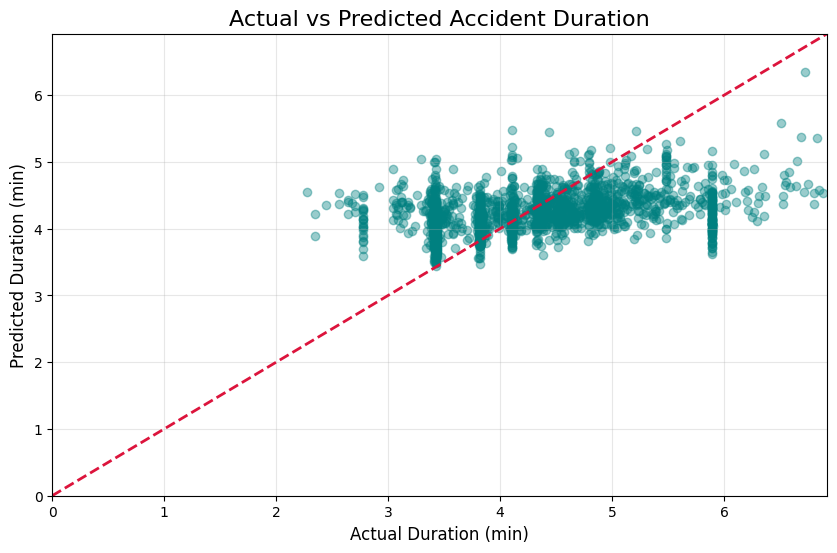

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# ส่วนที่แก้ไข: ใช้ df_train_engineered ทั้งหมดเลย
# ==========================================
df_final = df_train_engineered.copy()

# 1. เตรียมข้อมูล X และ y 
# เราต้องเอาคอลัมน์เป้าหมายทั้งหมดออกจากแกน X เพื่อป้องกัน Data Leakage
targets = ['Duration(min)', 'Distance(mi)', 'Log_Duration(min)', 'Log_Distance(mi)']
X = df_final.drop(columns=[col for col in targets if col in df_final.columns])

# กำหนด Target เป็น ระยะเวลา (แบบ Log)
y = df_final['Log_Duration(min)'] 
# ==========================================


# 2. แบ่งข้อมูลเป็น Train และ Validation (อัตราส่วน 80:20)
# เพื่อใช้ตรวจสอบว่าโมเดลเกิด Overfitting หรือไม่
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"ขนาดชุดข้อมูลเทรน: {X_train.shape}")
print(f"ขนาดชุดข้อมูลทดสอบ: {X_val.shape}")

# 3. กำหนดค่าและเทรนโมเดล XGBoost
# ตั้งค่าเบื้องต้นที่มักจะให้ผลลัพธ์ที่ดี (สามารถนำไปทำ Hyperparameter Tuning อย่าง GridSearch ต่อได้)
# 3. กำหนดค่าและเทรนโมเดล XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,       
    learning_rate=0.05,      
    max_depth=8,             
    subsample=0.8,           
    colsample_bytree=0.8,    
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50 # <--- ย้ายมาไว้ตรงนี้แทน
)

print("เริ่มการเทรนโมเดล XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100              # <--- ตรงนี้เหลือแค่ verbose
)

# 4. ทำนายผลบนชุด Validation
y_pred_log = xgb_model.predict(X_val)

# ... (โค้ดส่วนประเมินผลด้านล่างใช้เหมือนเดิมได้เลยครับ) ...

# ---------------------------------------------------------
# 5. การประเมินผล (Evaluation)
# ข้อควรระวัง: เราเทรนโมเดลด้วยค่า Log ดังนั้นต้องแปลงกลับเป็นนาที (Minute) ก่อนคำนวณ Error
# ---------------------------------------------------------
y_val_actual = np.expm1(y_val)
y_pred_actual = np.expm1(y_pred_log)

# คำนวณ Metrics เชิงเส้นตรง
rmse = np.sqrt(mean_squared_error(y_val_actual, y_pred_actual))
mae = mean_absolute_error(y_val_actual, y_pred_actual)
r2 = r2_score(y_val_actual, y_pred_actual)

print("\n=== ผลการประเมินประสิทธิภาพโมเดล ===")
print(f"RMSE (ความคลาดเคลื่อนรากที่สองเฉลี่ย): {rmse:.2f} นาที")
print(f"MAE (ความคลาดเคลื่อนสัมบูรณ์เฉลี่ย): {mae:.2f} นาที")
print(f"R-squared (เปอร์เซ็นต์ความแปรปรวนที่โมเดลอธิบายได้): {r2:.4f}")

# 6. พล็อตดูกราฟเปรียบเทียบค่าจริง vs ค่าทำนาย (เพื่อให้เห็นภาพชัดเจน)
plt.figure(figsize=(10, 6))
# สุ่มจุดมาพล็อตสัก 2,000 จุดเพื่อไม่ให้กราฟดูทึบเกินไป
sample_size = min(2000, len(y_val_actual))
plt.scatter(y_val_actual[:sample_size], y_pred_actual[:sample_size], alpha=0.4, color='teal')

# สร้างเส้นทแยงมุมอ้างอิง (ถ้าจุดทับเส้นนี้เป๊ะๆ แปลว่าทายถูก 100%)
max_val = max(y_val_actual[:sample_size].max(), y_pred_actual[:sample_size].max())
plt.plot([0, max_val], [0, max_val], '--', color='crimson', linewidth=2)

plt.xlabel("Actual Duration (min)", fontsize=12)
plt.ylabel("Predicted Duration (min)", fontsize=12)
plt.title("Actual vs Predicted Accident Duration", fontsize=16)
plt.xlim(0, max_val * 0.8) # ปรับสเกลให้อยู่ในระยะที่มองเห็นกลุ่มข้อมูลหลัก
plt.ylim(0, max_val * 0.8)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# df_train_clean = pd.read_csv("../../data/processed/01.3/accidents_advance_clean.csv")

# df_train_clean.head(10)